In [1]:
# ═══════════════════════════════════════════════════
#  消融实验 — 运行核心逻辑
# ═══════════════════════════════════════════════════
import sys
from pathlib import Path

PROJ = Path.cwd().parent
sys.path.insert(0, str(PROJ / "src"))

from logistics_delay.ablation.ablation import (
    load_and_prepare_data,
    run_feature_ablation,
    run_learning_curves,
    run_geo_ablation,
    save_results,
    save_geo_results,
)
from logistics_delay.features.engineering import FEATURES_XGB, XGB_CAT_COLS
from logistics_delay.utils.paths import TABLES_DIR, FIGURES_MODELS, ensure_output_dirs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# ── Publication style ──────────────────────────
PALETTE = {
    "blue_main": "#0F4D92", "blue_secondary": "#3775BA",
    "green_1": "#DDF3DE", "green_2": "#AADCA9", "green_3": "#8BCF8B",
    "red_1": "#F6CFCB", "red_2": "#E9A6A1", "red_strong": "#B64342",
    "neutral": "#CFCECE", "highlight": "#FFD700",
    "teal": "#42949E", "violet": "#9A4D8E",
}

plt.rcParams.update({
    "font.family": ["Arial", "SimHei", "DejaVu Sans", "sans-serif"],
    "font.size": 15,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 2.5,
    "legend.frameon": False,
    "svg.fonttype": "none",
})
plt.rcParams['axes.unicode_minus'] = False
ensure_output_dirs()

# ── 最佳 CatBoost 超参数 (来自 04_tuning.ipynb) ──
BEST_CB_PARAMS = {
    "learning_rate": 0.05,
    "depth": 8,
    "iterations": 100,
    "l2_leaf_reg": 5,
    "border_count": 64,
    "bagging_temperature": 1,
    "random_strength": 0,
}

print("=" * 60)
print("  运行消融实验 — 最佳超参数版")
print(f"  参数: {BEST_CB_PARAMS}")
print("=" * 60)

df_sorted = load_and_prepare_data()

ablation_results = run_feature_ablation(
    df_sorted,
    feature_list=FEATURES_XGB,
    catboost_params=BEST_CB_PARAMS,
)
lc_results = run_learning_curves(
    df_sorted,
    feature_list=FEATURES_XGB,
    ablation_df=ablation_results,
    catboost_params=BEST_CB_PARAMS,
)
save_results(ablation_results, lc_results, save_dir=TABLES_DIR)

geo_results = run_geo_ablation(df_sorted, catboost_params=BEST_CB_PARAMS)
save_geo_results(geo_results, save_dir=TABLES_DIR)

print(f"\n特征消融: {len(ablation_results)} 行")
print(f"累积学习曲线: {len(lc_results)} 步")
print(f"地理消融: {len(geo_results)} 方案")

  运行消融实验 — 最佳超参数版
  参数: {'learning_rate': 0.05, 'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'border_count': 64, 'bagging_temperature': 1, 'random_strength': 0}
[loader] 预处理数据加载完成: (6854, 54)
[loader] 延误率: 63.19%
[data] 最终形状: (6854, 54)
[data] 正样本比例: 0.6319

  特征消融实验 (CatBoost Leave-One-Out)
[split] 训练: 5483 / 测试: 1371, spw=0.3818
[full] AUC = 83.49%  F1 = 0.7037
  去掉 TRANSPORTATION_DISTANCE_IN_KM   AUC = 84.09%  (drop=-0.60pp)  F1 = 0.6748  (drop=+2.8895pp)
  去掉 is_market                       AUC = 83.49%  (drop=+0.00pp)  F1 = 0.7037  (drop=+0.0000pp)
  去掉 start_weekday                   AUC = 84.12%  (drop=-0.63pp)  F1 = 0.7139  (drop=-1.0152pp)
  去掉 start_month                     AUC = 85.55%  (drop=-2.07pp)  F1 = 0.7305  (drop=-2.6802pp)
  去掉 planned_days_enc                AUC = 61.01%  (drop=+22.48pp)  F1 = 0.3922  (drop=+31.1547pp)
  去掉 supplier_is_large               AUC = 83.49%  (drop=+0.00pp)  F1 = 0.7037  (drop=+0.0000pp)
  去掉 vehicleType                     AUC = 83.

In [2]:
# ═══════════════════════════════════════════════════
#  默认参数地理消融实验（对比用）
# ═══════════════════════════════════════════════════
DEFAULT_CB_PARAMS = {"iterations": 200}

print("=" * 60)
print("  运行地理消融实验 — 默认参数版")
print("=" * 60)

geo_results_default = run_geo_ablation(df_sorted, catboost_params=DEFAULT_CB_PARAMS)

# 保存默认参数结果到独立文件
default_geo_path = TABLES_DIR / "geo_ablation_default_results.csv"
geo_results_default.to_csv(default_geo_path, index=False, encoding="utf-8-sig")
print(f"[OK] 默认参数地理消融结果 → {default_geo_path}")

print("\n最佳参数 vs 默认参数 AUC 对比:")
comp = geo_results[["strategy", "auc"]].copy()
comp.columns = ["strategy", "auc_best"]
comp["auc_default"] = geo_results_default["auc"].values
comp["auc_diff_pp"] = (comp["auc_best"] - comp["auc_default"]) * 100
for _, row in comp.iterrows():
    diff_str = f"+{row['auc_diff_pp']:.2f}pp" if row['auc_diff_pp'] > 0 else f"{row['auc_diff_pp']:.2f}pp"
    print(f"  {row['strategy']:<10s}  最佳={row['auc_best']*100:.2f}%  默认={row['auc_default']*100:.2f}%  "
          f"差值={diff_str}")

  运行地理消融实验 — 默认参数版

  地理消融实验
  缺失距离: 705 / 6854
  中位数: 160.00, 均值: 555.21
  Geo                   AUC=77.89%  F1=0.6036
  Median                AUC=74.36%  F1=0.5220
  Mean                  AUC=81.54%  F1=0.6284
[OK] 默认参数地理消融结果 → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\tables\geo_ablation_default_results.csv

最佳参数 vs 默认参数 AUC 对比:
  Geo         最佳=83.49%  默认=77.89%  差值=+5.60pp
  Median      最佳=81.90%  默认=74.36%  差值=+7.54pp
  Mean        最佳=81.47%  默认=81.54%  差值=-0.07pp


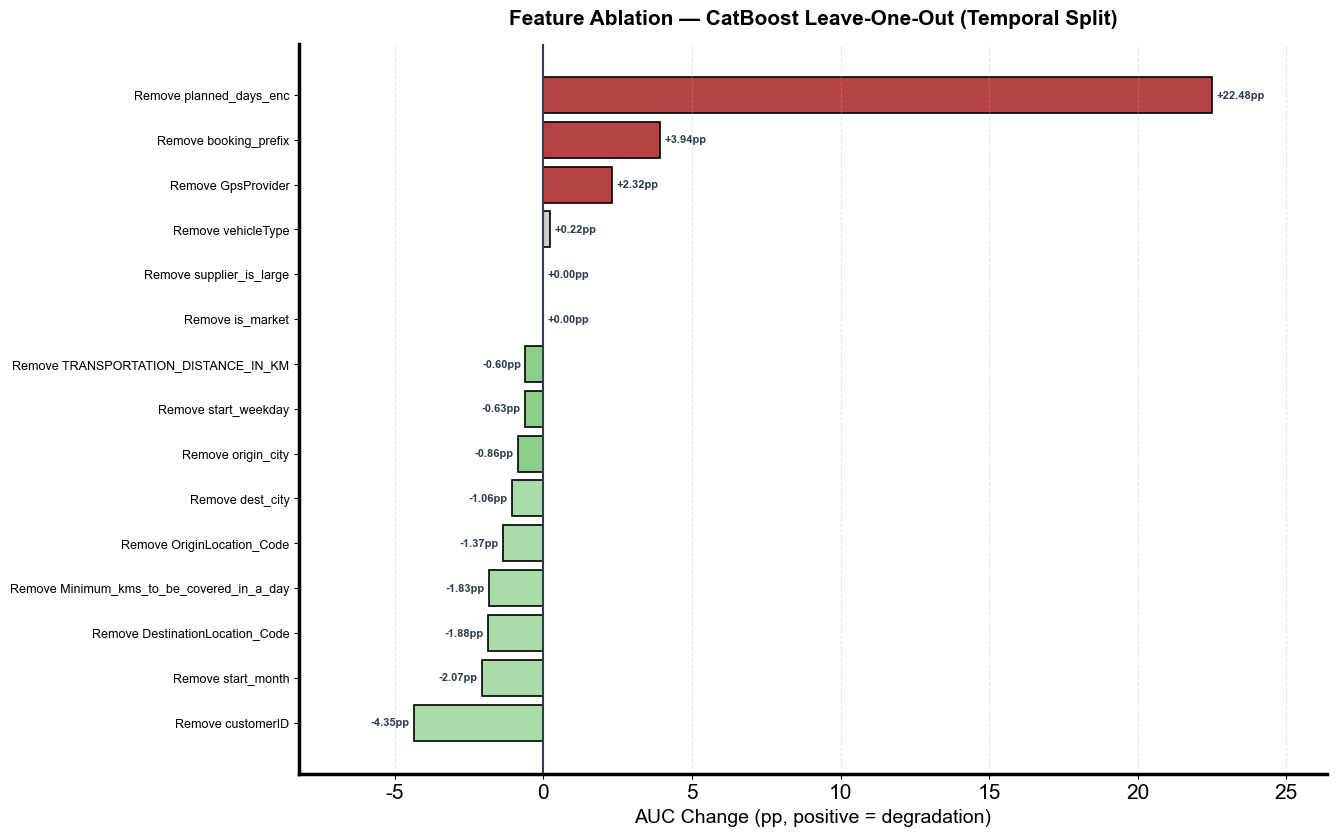

[OK] 已保存 → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\feature_ablation_bar.png


In [3]:
# ═══════════════════════════════════════════════════
#  特征消融条形图 — 按 AUC 下降幅度排序
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 9))

sub = ablation_results[ablation_results["removed_feat"] != "（全特征基准）"] \
    .sort_values("auc_drop", ascending=True).copy()

def _bar_color(val: float) -> str:
    if val > 1.0:
        return PALETTE['red_strong']
    elif val > 0.3:
        return PALETTE['red_2']
    elif val > -0.3:
        return PALETTE['neutral']
    elif val > -1.0:
        return PALETTE['green_3']
    else:
        return PALETTE['green_2']

colors = [_bar_color(v) for v in sub["auc_drop"]]
bars = ax.barh(range(len(sub)), sub["auc_drop"].values,
               color=colors, edgecolor="black", linewidth=1.2)

ax.axvline(0, color="#2c3e50", linestyle="-", linewidth=1.5)
ax.set_yticks(range(len(sub)))
ax.set_yticklabels(["Remove " + r["removed_feat"] for _, r in sub.iterrows()], fontsize=9)

# Place value labels at bar edges to avoid overlap
for bar, val in zip(bars, sub["auc_drop"].values):
    if val >= 0:
        # Positive: label to the right of bar end
        x_pos = val + 0.15
        ha = "left"
    else:
        # Negative: label to the left of bar end (inside margin)
        x_pos = val - 0.15
        ha = "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.2f}pp", va="center", ha=ha,
            fontsize=8, fontweight="bold", color="#2c3e50")

# Add x-axis margin so bars don't collide with ytick labels
x_pad = max(abs(sub["auc_drop"].min()), abs(sub["auc_drop"].max())) * 0.15 + 0.5
ax.set_xlim(sub["auc_drop"].min() - x_pad, sub["auc_drop"].max() + x_pad)

ax.set_xlabel("AUC Change (pp, positive = degradation)", fontsize=14)
ax.set_title("Feature Ablation — CatBoost Leave-One-Out (Temporal Split)",
             fontsize=15, fontweight="bold", pad=14)
ax.grid(axis="x", linestyle="--", alpha=0.3)

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / 'feature_ablation_bar.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_MODELS / 'feature_ablation_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"[OK] 已保存 → {FIGURES_MODELS / 'feature_ablation_bar.png'}")

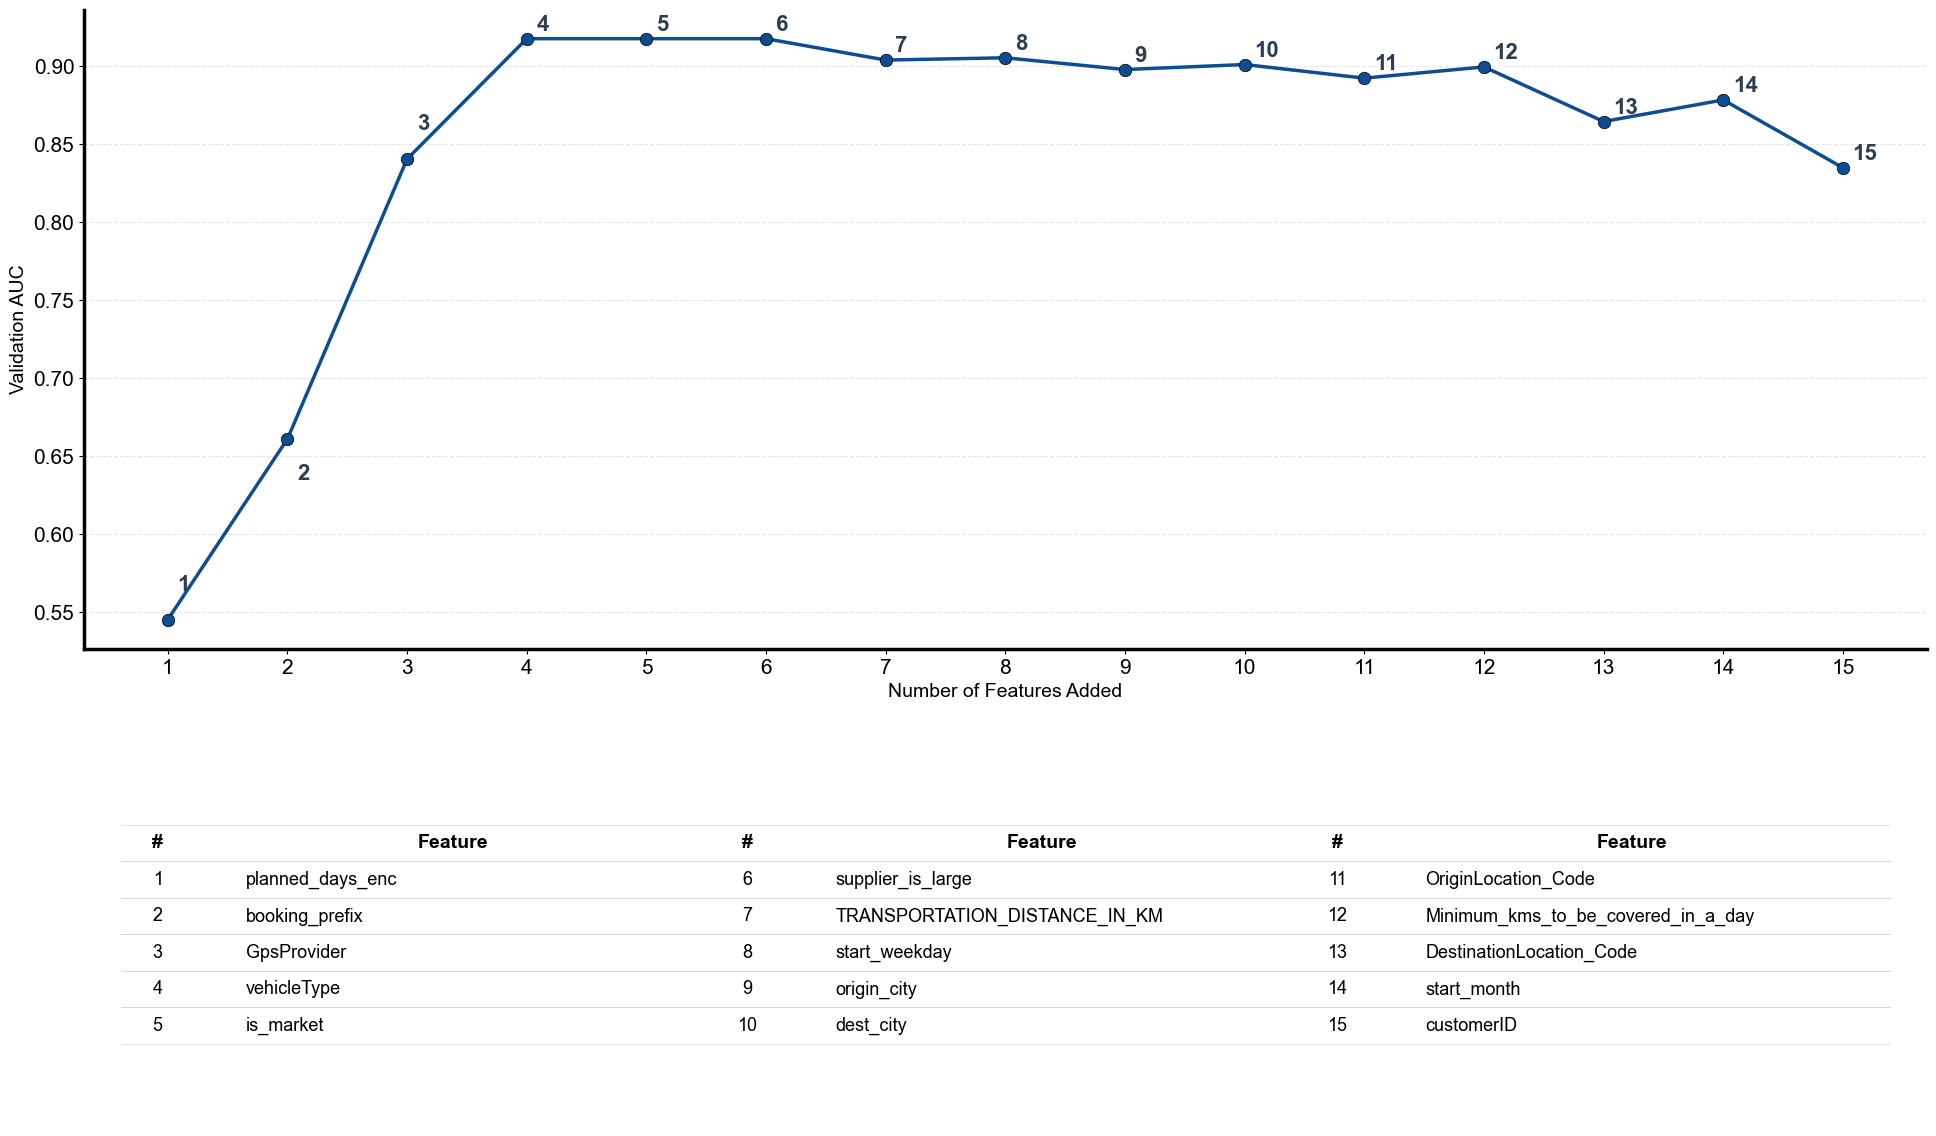

[OK] 已保存 → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\learning_curves.png


In [4]:
# ═══════════════════════════════════════════════════
#  累积特征学习曲线 + 编号对照表
# ═══════════════════════════════════════════════════
fig, (ax_plot, ax_tbl) = plt.subplots(
    2, 1, figsize=(20, 12),
    gridspec_kw={"height_ratios": [2, 1.2]},
)

# ── 曲线 ──
ax_plot.plot(lc_results["n_features"], lc_results["auc"],
             marker="o", linestyle="-", linewidth=2.5, color=PALETTE['blue_main'],
             markersize=9, markeredgecolor='black', markeredgewidth=0.5)

for i, (_, row) in enumerate(lc_results.iterrows()):
    # 前三个点密集，交替上下偏移避免编号与连线重叠
    if i < 3:
        y_offset = 18 if i % 2 == 0 else -18
        va = "bottom" if y_offset > 0 else "top"
    else:
        y_offset = 3
        va = "bottom"
    ax_plot.annotate(
        str(i + 1),
        xy=(row["n_features"], row["auc"]),
        xytext=(7, y_offset),
        textcoords="offset points",
        fontsize=16, fontweight="bold", color="#2c3e50",
        va=va, ha="left",
    )

ax_plot.set_xlabel("Number of Features Added", fontsize=14)
ax_plot.set_ylabel("Validation AUC", fontsize=14)
ax_plot.set_xticks(range(1, len(lc_results) + 1))
ax_plot.grid(axis='y', linestyle='--', alpha=0.3)

# ── 编号对照表（每 5 个换列，共 3 组）──
ax_tbl.axis("off")
n = len(lc_results)
n_groups = 3
rows_per = 5

flat_headers = []
for g in range(n_groups):
    flat_headers.extend(["#", "Feature"])

tbl_rows = []
for r in range(rows_per):
    row = []
    for g in range(n_groups):
        idx = r + g * rows_per
        if idx < n:
            row.extend([str(idx + 1), lc_results.iloc[idx]["feature_added"]])
        else:
            row.extend(["", ""])
    tbl_rows.append(row)

# 列宽用轴坐标（必须合计 ≤ 1.0）
col_ws = [0.04, 0.28, 0.04, 0.28, 0.04, 0.28]

table = ax_tbl.table(
    cellText=tbl_rows,
    colLabels=flat_headers,
    loc="center",
    cellLoc="left",
    colWidths=col_ws,
    edges="horizontal",
)
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 1.8)

for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor("#cccccc")
    cell.set_linewidth(0.4)
    if row_idx == 0:
        cell.set_text_props(fontweight="bold", fontsize=14)
    elif row_idx % 2 == 0:
        cell.set_facecolor("#f0f0f0")
    if col_idx % 2 == 0:
        cell.set_text_props(ha="center")

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / 'learning_curves.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_MODELS / 'learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"[OK] 已保存 → {FIGURES_MODELS / 'learning_curves.png'}")

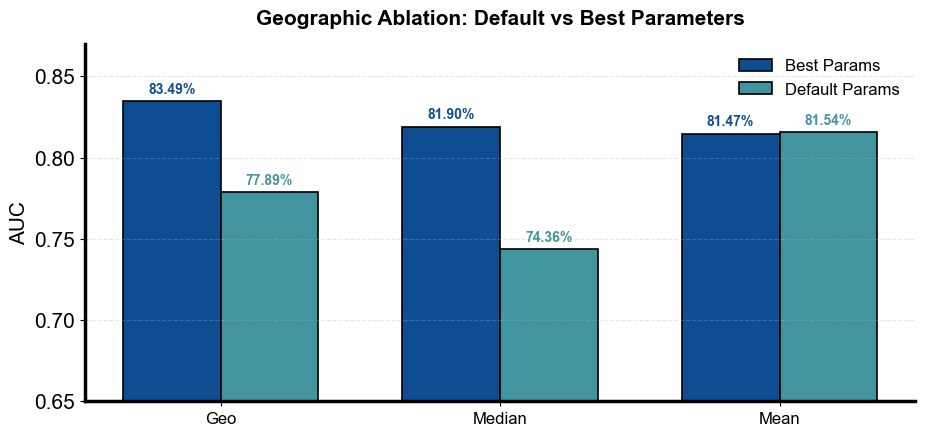

[OK] 已保存 → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\geo_ablation_default_vs_best.png


In [5]:
# ═══════════════════════════════════════════════════
#  地理消融对比图：默认参数 vs 最优参数
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(geo_results))
width = 0.35

bars_best = ax.bar(x - width/2, geo_results["auc"], width,
                   color=PALETTE['blue_main'], edgecolor='black', linewidth=1.2,
                   label='Best Params')
bars_default = ax.bar(x + width/2, geo_results_default["auc"], width,
                      color=PALETTE['teal'], edgecolor='black', linewidth=1.2,
                      label='Default Params')

for bar, auc_val in zip(bars_best, geo_results["auc"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{auc_val*100:.2f}%", ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=PALETTE['blue_main'])

for bar, auc_val in zip(bars_default, geo_results_default["auc"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{auc_val*100:.2f}%", ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=PALETTE['teal'])

ax.set_xticks(x)
ax.set_xticklabels(geo_results["strategy"], fontsize=12)
ax.set_ylabel("AUC", fontsize=15)
ax.set_title("Geographic Ablation: Default vs Best Parameters",
             fontsize=15, fontweight='bold', pad=14)
ax.legend(fontsize=12)
ax.set_ylim(0.65, 0.87)
ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / 'geo_ablation_default_vs_best.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_MODELS / 'geo_ablation_default_vs_best.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"[OK] 已保存 → {FIGURES_MODELS / 'geo_ablation_default_vs_best.png'}")